# Workshop on Genetics
by Kaylee Vo and Tadhg Scannell

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Customize for matplotlib
# If interested in the matplotlib object hierarchy, check: https://realpython.com/python-matplotlib-guide/
plt.rcParams["axes.linewidth"] = 1
plt.rcParams["xtick.bottom"] = True
plt.rcParams["ytick.left"] = True
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["mathtext.default"] = "regular"
# Change font size: http://www.futurile.net/2016/02/27/matplotlib-beautiful-plots-with-style/
plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 14
plt.rcParams["figure.titlesize"] = 20

# Problem 1

**Define the states and construct the transition matrix of the system, in canonical form**

There are six states, based on the geneology of an individuals parents.  Those states are


*   HY: One parent is HH, the other parent is YY
*   MM: Both parents are either HY or YH
*   HM: One parent is YY and the other is either HY or YH
*   YM: One parent is YY and the other is either HY or YH
*   HH: Both parents are HH
*   YY: Both parents are YY

Given the constraint that two individuals will marry and have children only if their respective parents have the same geneotype, we can calculate the combination of outcomes for the n+1 generation couple geneotype based on the n generation couple geneotype.  

1.   For couples where their parents are HH, the only possible outcome is HH.  
The parents genes are "hh" and "hh", so all four combinations of genes results in a HH combination
2.  For couples where their parents are YY, the only possible outcome is YY.  The parents genes are "yy" and "yy", so all four combinations of genes results in a YY couple
3.   For couples where their parents are HY, the only possible outcome is MM.  The parents genes are of the combination "hh" and "yy", so the only possible outcomes are "hy" or "yh".
4.   For couples where their parents are HM, their parents are of the geneotype "hh" and either "yh" or "hy".  The possible outcomes (and associated probability) for children of this combination are "hh"(1/2), "yh"(1/4), or "hy"(1/4).  As there are two parents, we need to calculate out the matches by mulitplying the liklihood of that first parents geneotype times the liklihood that the second parent is each.  
  *    "hh" * "hh" = 0.5 * 0.5 = 1/4.  This leads to a HH generation.
  *    "hh" * "yh" = 0.5 * 0.25 = 1/8.  This leads to a HM next generation.  By symmetry, this is the same as "yh" * "hh", doubling this outcome probability to 1/4   
  *    "hh" * "hy" = 0.5 * 0.5 = 1/8.  This leads to a HM next generation. By symmetry, this is the same as "hy" * "hh", doubling this to 1/4.  
  *    "yh" * "yh" = 0.25 * 0.25 = 1/16.  This leads to a MM next generation. By symmetry, this is the same as "hy" * "yh", "yh" * "hy" and "hy" * "hy".  This leads to a total probability of 1/4.

5.   For couples where their parents are YM, their parents are of the geneotype "hh" and either "yh" or "hy".  The possible outcomes (and associated probability) for children of this combination are "yy"(1/2), "yh"(1/4), or "hy"(1/4).  As there are two parents, we need to calculate out the matches by mulitplying the liklihood of that first parents geneotype times the liklihood that the second parent is each.
  *    "yy" * "yy" = 0.5 * 0.5 = 1/4.  This leads to a YY generation.
  *    "yy" * "yh" = 0.5 * 0.25 = 1/8.  This leads to a YM next generation.  By symmetry, this is the same probability as "yh" * "yy", doubling this to 1/4.
  *    "yy" * "hy" = 0.5 * 0.5 = 1/8.  This leads to a YM next generation. By symmetry, this is the same probability as "hy" * "yy", doubling this to 1/4.  
  *    "yh" * "yh" = 0.25 * 0.25 = 1/16.  This leads to a MM next generation.  By symmetry, this is the same probability as "hy" * "yh", "yh" * "hy" and "hy" * "hy".  This leads to a total probability of 1/4.  

6. For couples where their parents are MM geneotype, their parents of the genotype combinations where both are of either are "hy" or "yh".  The possible outcomes (and associated probability) for children of this combination are "hh" (1/4), "hy" (1/4), "yh" (1/4), and "yy" (1/4). As there are two parents, we need to calculate out the matches by mulitplying the liklihood of that first parents geneotype times the liklihood that the second parent is each.
  *    "yy" * "yy" = 0.25 * 0.25 = 1/16.  This leads to a YY generation.
  *    "hh" * "hh" = 0.25 * 0.25 = 1/16.  This leads to a HH generation.
  *    "yy" * "yh" = 0.25 * 0.25 = 1/16.  This leads to a YM next generation.  By symmetry, this is the same probability as "yh" * "yy", "yy" * "hy" and "hy" * "yy" increasing this to 1/4.
  *    "hh" * "yh" = 0.25 * 0.25 = 1/16.  This leads to a HM next generation.  By symmetry, this is the same probability as "yh" * "hh", "hh" * "hy" and "hy" * "hh" increasing this to 1/4   
  *    "yh" * "yh" = 0.25 * 0.25 = 1/16.  This leads to an MM generation.  By symmetry, this is the same probability as ("hy" * "yh"), ("hy" * "hy"), ("yh" * "hy") increasing the probability to 1/4.

  *    "yy" * "hh" = .25 * .25 =1/16.  This leads to a HY next generation.  By symmetry, this is the same probability as "hh" * "yy", increasing the total probability to 1/8.



The diagram relecting this is shown below with the probabilities of each transition.

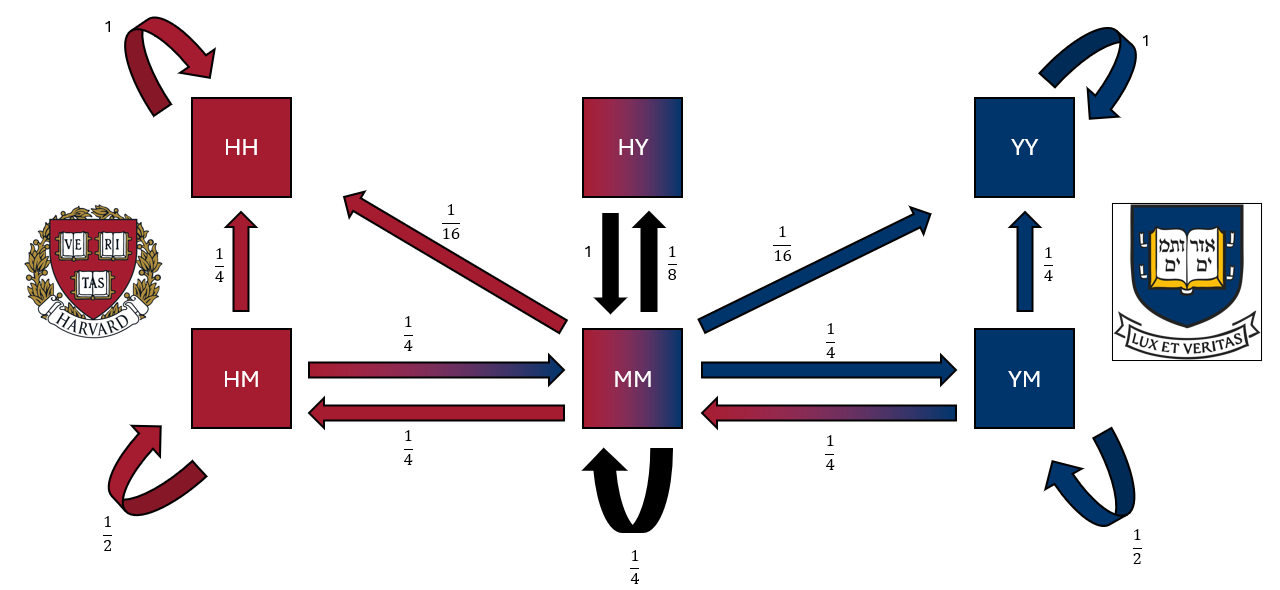

From this, it is apparent that there are two absorving states, HH and YY.  This turns into the transition matrix below, which is in the canonical form.

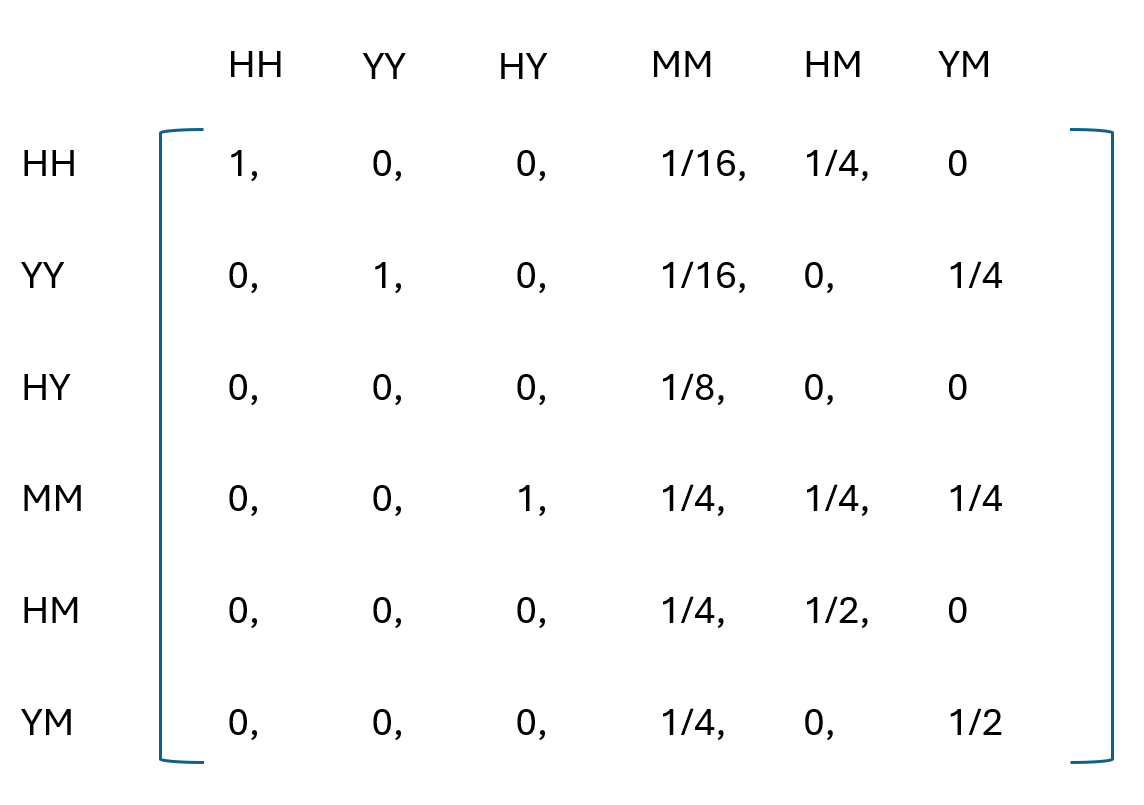

# Problem 2

Numerically evolve the probability vector (i.e. multiply the probability vector by the
transition matrix) to equilibrium for some different initial conditions as prescribed below.


How does the initial size of the student populations affect the final probabilities?

Try:
i. equal number of people of a certain phenotype:
* Y = 1/2,
* H = 1/4,
* M = 1/4

ii. equal number of people of a certain genotype:
* Y = 1/3,
* H = 1/3,
* M = 1/3

Do you agree with the MIT scientists?

The transition matrix, in python, is shown below

In [230]:
transition_matrix = [[1, 0, 0, 1/16, 1/4, 0],[0, 1, 0, 1/16, 0, 1/4],[0, 0, 0, 1/8, 0, 0],[0, 0, 1, 1/4, 1/4, 1/4],[0, 0, 0, 1/4, 1/2, 0], [0, 0, 0, 1/4, 0, 1/2]]
print(transition_matrix)

[[1, 0, 0, 0.0625, 0.25, 0], [0, 1, 0, 0.0625, 0, 0.25], [0, 0, 0, 0.125, 0, 0], [0, 0, 1, 0.25, 0.25, 0.25], [0, 0, 0, 0.25, 0.5, 0], [0, 0, 0, 0.25, 0, 0.5]]


The probability matrixes can be found by finding the combinations of each option.  

For i, the initial probabilities are
* Y * Y = 1/2 * 1/2 = 1/4
* H * H = 1/4 * 1/4 = 1/16
* H * Y = 1/4 * 1/2 = 1/8  This is the same as Y * H so the probability is increased to 1/4
* Y * M = 1/2 * 1/4 = 1/8.  This is the same as M * Y so the probability is increased to 1/4
* H * M = 1/4 * 1/4 = 1/16.  This is the same as M * Y so the probability is increased to 1/8
* M * M = 1/4 * 1/4 = 1/16

Therefore the probability matrix is:

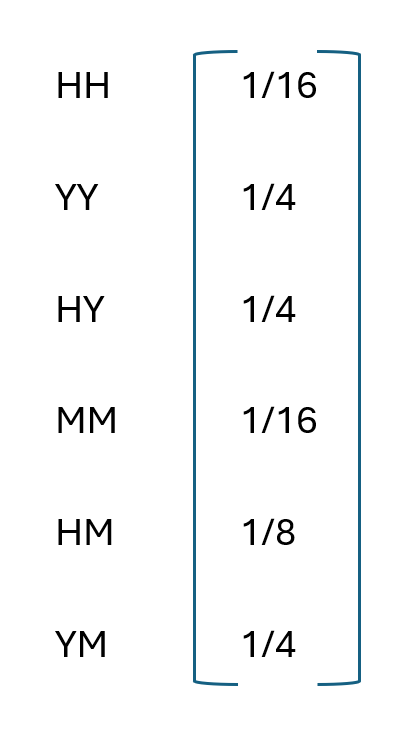

And the python variable is

In [222]:
i_probability_matrix = [[1/16],[1/4],[1/4],[1/16],[1/8], [1/4]]
print(i_probability_matrix)

[[0.0625], [0.25], [0.25], [0.0625], [0.125], [0.25]]


Now to get to the absorbing state, we multiply until only the absobing states remain

In [249]:
Number_of_Iterations = 0

matrix_to_hold=i_probability_matrix

while(round(matrix_to_hold[2][0]+matrix_to_hold[3][0]+matrix_to_hold[4][0]+matrix_to_hold[5][0], 3) != 0.0):
  matrix_to_hold = np.dot(transition_matrix, matrix_to_hold)
  Number_of_Iterations+=1

print("Number of Iterations: " + str(Number_of_Iterations))
print("Probability Matrix: ")
print(matrix_to_hold)
print("HH probability rounded two 2 decimals = " + str(round(matrix_to_hold[0][0],3)))
print("YY probability rounded two 2 decimals = " + str(round(matrix_to_hold[1][0],3)))

Number of Iterations: 35
Probability Matrix: 
[[3.74775268e-01]
 [6.24775268e-01]
 [2.50477256e-05]
 [1.62112286e-04]
 [1.31151592e-04]
 [1.31151596e-04]]
HH probability rounded two 2 decimals = 0.375
YY probability rounded two 2 decimals = 0.625


For ii, the initial probabilities are
* Y * Y = 1/3 * 1/3 = 1/9
* H * H = 1/3 * 1/3 = 1/9
* H * Y = 1/3 * 1/3 = 1/9  This is the same as Y * H so the probability is increased to 2/9
* Y * M = 1/3 * 1/3 = 1/9.  This is the same as M * Y so the probability is increased to 2/9
* H * M = 1/3 * 1/3 = 1/9.  This is the same as M * Y so the probability is increased to 2/9
* M * M = 1/3 * 1/3 = 1/9

Therefore the probability matrix is:

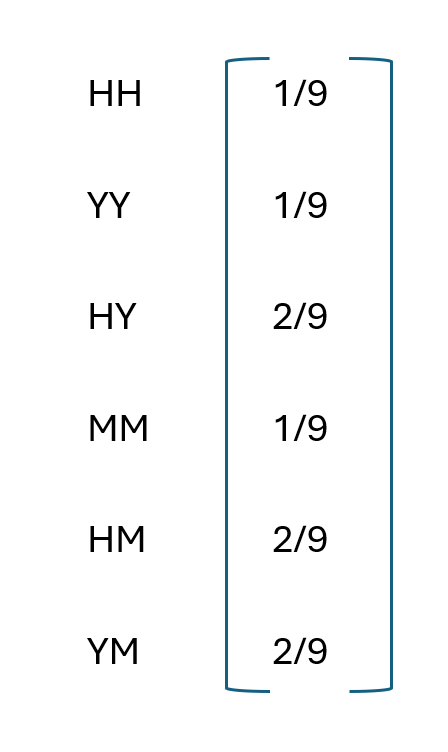

In [251]:
ii_probability_matrix = [[1/9],[1/9],[2/9],[1/9],[2/9], [2/9]]
print(ii_probability_matrix)

[[0.1111111111111111], [0.1111111111111111], [0.2222222222222222], [0.1111111111111111], [0.2222222222222222], [0.2222222222222222]]


In [252]:
Number_of_Iterations = 0

matrix_to_hold=ii_probability_matrix

while(round(matrix_to_hold[2][0]+matrix_to_hold[3][0]+matrix_to_hold[4][0]+matrix_to_hold[5][0], 3) != 0.0):
  matrix_to_hold = np.dot(transition_matrix, matrix_to_hold)
  Number_of_Iterations+=1

print("Number of Iterations: " + str(Number_of_Iterations))
print("Probability Matrix: ")
print(matrix_to_hold)
print("HH probability rounded two 2 decimals = " + str(round(matrix_to_hold[0][0],3)))
print("YY probability rounded two 2 decimals = " + str(round(matrix_to_hold[1][0],3)))

Number of Iterations: 35
Probability Matrix: 
[[4.99751807e-01]
 [4.99751807e-01]
 [2.76626427e-05]
 [1.79036385e-04]
 [1.44843478e-04]
 [1.44843478e-04]]
HH probability rounded two 2 decimals = 0.5
YY probability rounded two 2 decimals = 0.5


From this, we do not agree with the MIT scientists.  In the final states for both i and ii, where the entire population is in either abosrbing state, there are still sizeable populations of both the HH and the YY populations.

# Problem 3

# Problem 4

In [ ]:
class IvyLeaguer:
    def __init__(self, id, genes, parents_geneotype):
        self.id = id
        self.genes = genes
        self.parents_geneotype = parents_geneotype
        self.married = False
        self.spouse_id = None

In [ ]:
def initialize_population(populationSize, harvardPercentage, yalePercentage, mixedPercentage):
  # Initialize
  population = []

  for i in range(populationSize):
    print
    determination_variable = np.random.random()

    if determination_variable < HARVARD_PERCENTAGE:
      genes = "HH"
      population.append(IvyLeaguer(i, genes, None))
    elif determination_variable < YALE_PERCENTAGE+HARVARD_PERCENTAGE:
      genes = "YY"
      population.append(IvyLeaguer(i, genes, None))
    else:
      new_determination_variable = np.random.random()
      if new_determination_variable < .5:
        genes = "HY"
        population.append(IvyLeaguer(i, genes, None))
      else:
        genes = "YH"
        population.append(IvyLeaguer(i, genes, None))

  return population

In [ ]:
def check_compatibility(romeo, juliet):
  if (romeo.id != juliet.id) and (romeo.married==False and juliet.married == False) and (romeo.parents_geneotype == romeo.parents_geneotype):
        return True
  return False

In [ ]:
def marriage(romeo, juliet):
  romeo.spouse_id = juliet.id
  juliet.spouse_id = romeo.id
  romeo.married = True
  juliet.married = True

In [ ]:
def create_child(child_id, romeo, juliet):
    determination_variable = np.random.random()

    # Determine Child Genes
    if determination_variable < 0.25:
        child_genes = romeo.genes[0] + juliet.genes[0]
    elif determination_variable < 0.5:
        child_genes = juliet.genes[0] + romeo.genes[1]
    elif determination_variable < 0.75:
        child_genes = juliet.genes[1] + romeo.genes[0]
    else:
        child_genes = romeo.genes[1] + juliet.genes[1]


    parent_genes=[]
    # Get Parent Geneotype
    match romeo.genes:
      case "HH":
        parent_genes.append("H")
      case "YY":
        parent_genes.append("Y")
      case "HY":
        parent_genes.append("M")
      case "YH":
        parent_genes.append("M")

    # Get Parent Geneotype
    match juliet.genes:
      case "HH":
        parent_genes.append("H")
      case "YY":
        parent_genes.append("Y")
      case "HY":
        parent_genes.append("M")
      case "YH":
        parent_genes.append("M")

    return IvyLeaguer(child_id, child_genes, parent_genes)

In [ ]:
# Population Finds Spouses

def iterate_generation(population, number_of_children, id_start):
  next_generation = []

  next_id=id_start

  for member in population:
    if member.married == False:

      for other_member in population:

        if check_compatibility(member, other_member):
          marriage(member, other_member)

          for i in range(number_of_children):
            next_generation.append(create_child(next_id, member, other_member))
            next_id+=1

          break


  return next_generation



In [ ]:
Number_of_Generations = 0
harvard_count=0
yale_count=0
mixed_count=1

#Set Population Variables
HARVARD_PERCENTAGE = 1/3
YALE_PERCENTAGE = 1/3
MIXED_PERCENTAGE = 1/3
populationSize = 100

#Population Array
population = initialize_population(populationSize, HARVARD_PERCENTAGE, YALE_PERCENTAGE, MIXED_PERCENTAGE)

while not (mixed_count == 0)  :
  Number_of_Generations+=1
  population = iterate_generation(population, 2, 101)
  harvard_count=0
  yale_count=0
  mixed_count=0
  for x in population:
    if x.genes == "HH":
      harvard_count+=1
    elif x.genes == "YY":
      yale_count+=1
    elif x.genes == "HY" or "YH":
      mixed_count+=1
    else:
      print("Weird Genes: " + i.genes)
  Number_of_Generations += 1

print("Generation: " + str(Number_of_Generations))
print("Harvard Count: " + str(harvard_count))
print("Yale Count: " + str(yale_count))
print("Mixed Count: " + str(mixed_count))

Generation: 70
Harvard Count: 46
Yale Count: 54
Mixed Count: 0


In [258]:
Number_of_Generations = 0
harvard_count=0
yale_count=0
mixed_count=1

#Set Population Variables
HARVARD_PERCENTAGE = 1/3
YALE_PERCENTAGE = 1/3
MIXED_PERCENTAGE = 1/3
populationSize = 1000

#Population Array
population = initialize_population(populationSize, HARVARD_PERCENTAGE, YALE_PERCENTAGE, MIXED_PERCENTAGE)

while not (mixed_count == 0)  :
  Number_of_Generations+=1
  population = iterate_generation(population, 2, 101)
  harvard_count=0
  yale_count=0
  mixed_count=0
  for x in population:
    if x.genes == "HH":
      harvard_count+=1
    elif x.genes == "YY":
      yale_count+=1
    elif x.genes == "HY" or "YH":
      mixed_count+=1
    else:
      print("Weird Genes: " + i.genes)
  Number_of_Generations += 1

print("Generation: " + str(Number_of_Generations))
print("Harvard Count: " + str(harvard_count))
print("Yale Count: " + str(yale_count))
print("Mixed Count: " + str(mixed_count))

Generation: 86
Harvard Count: 494
Yale Count: 506
Mixed Count: 0


In [257]:
Number_of_Generations = 0
harvard_count=0
yale_count=0
mixed_count=1

#Set Population Variables
HARVARD_PERCENTAGE = 1/4
YALE_PERCENTAGE = 1/2
MIXED_PERCENTAGE = 1/4
populationSize = 1000

#Population Array
population = initialize_population(populationSize, HARVARD_PERCENTAGE, YALE_PERCENTAGE, MIXED_PERCENTAGE)

while not (mixed_count == 0)  :
  Number_of_Generations+=1
  population = iterate_generation(population, 2, 101)
  harvard_count=0
  yale_count=0
  mixed_count=0
  for x in population:
    if x.genes == "HH":
      harvard_count+=1
    elif x.genes == "YY":
      yale_count+=1
    elif x.genes == "HY" or "YH":
      mixed_count+=1
    else:
      print("Weird Genes: " + i.genes)
  Number_of_Generations += 1

print("Generation: " + str(Number_of_Generations))
print("Harvard Count: " + str(harvard_count))
print("Yale Count: " + str(yale_count))
print("Mixed Count: " + str(mixed_count))

Generation: 82
Harvard Count: 376
Yale Count: 624
Mixed Count: 0
